Calcul 1 : taux de réservation moyen par mois par type de logement → il faut comprendre comment le taux est calculé (disponibilités vs jours du mois)  
Calcul 2 : médiane du nombre d'avis pour tous les logements → df.median() sur la colonne avis  
Calcul 3 : médiane du nombre d'avis par catégorie d'hôte (super hôte vs non super hôte) → group_by + médiane  
Calcul 4 : densité de logements par quartier → compter les logements par quartier, rapporter à la surface ou juste le count  
Calcul 5 : quartiers avec le plus fort taux de réservation par mois → croiser quartier + mois + taux  

In [ ]:
# Library
import os
import polars as pl 
from dotenv import load_dotenv
from pymongo import MongoClient 
import matplotlib.pyplot as plt


In [16]:
# Connexion et instance
load_dotenv()
uri = os.getenv("NONGO_URI")
client = MongoClient(uri)
db = client['airbnb']
collection = db['listings']
client.admin. command('ping')

{'ok': 1.0}

In [22]:
docs = list(collection.find({}, {"_id":0}))
df = pl.DataFrame(docs)

In [24]:
df.columns

['id',
 'listing_url',
 'name',
 'description',
 'picture_url',
 'price',
 'license',
 'availability',
 'host',
 'location',
 'night',
 'property',
 'review',
 'scraping']

In [48]:
# Q1

dfq1 = df.unnest('availability').unnest('property')

dfq1.with_columns(
    ((30 - pl.col("availability_30")) / 30).alias("taux"
)).group_by(pl.col("room_type")).agg((
    pl.col("taux").mean().alias("taux_moyen")*100).round(2)
)

room_type,taux_moyen
str,f64
"""Private room""",70.29
"""Shared room""",60.72
"""Entire home/apt""",71.29
"""Hotel room""",53.53


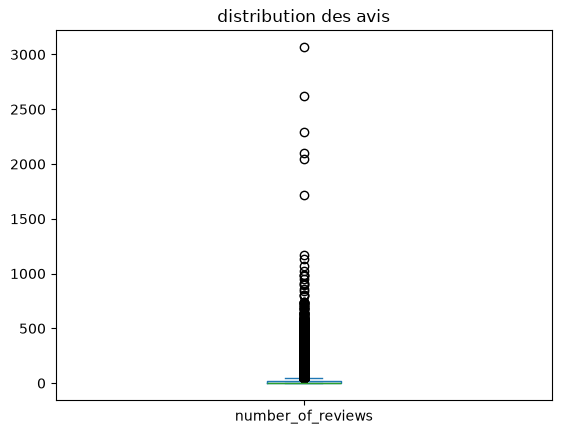

In [47]:
# Q2
import matplotlib.pyplot as plt

dfq2 = df.unnest('review')
dfq2['number_of_reviews'].median()

dfq2['number_of_reviews'].to_pandas().plot.box()
plt.title("distribution des avis")
plt.show()


In [51]:
# Q3: Médiane du nombre d'avis par catégorie d'hôte (super hôte vs non super hôte) 
dfq3 = df.unnest('review').unnest('host')

dfq3.with_columns(
    pl.col("number_of_reviews")
    ).group_by(pl.col("host_is_superhost")).agg(
    pl.col("number_of_reviews").median().alias("mediane_avis_host")
)


host_is_superhost,mediane_avis_host
bool,f64
false,2.0
null,12.5
true,24.0


In [61]:
# Q4: 
df.unnest('location').group_by(
    pl.col("neighbourhood_cleansed")).len().sort(
        "len", descending=False)


neighbourhood_cleansed,len
str,u32
"""Louvre""",2026
"""Luxembourg""",2701
"""Palais-Bourbon""",2740
"""Hôtel-de-Ville""",2821
"""Élysée""",2898
…,…
"""Entrepôt""",6558
"""Batignolles-Monceau""",6857
"""Vaugirard""",7802


In [66]:
# Q5: 

dfq5 = df.unnest('availability').unnest('location')

dfq5.with_columns(
    ((30 - pl.col("availability_30")) / 30).alias("taux"
)).group_by(pl.col("neighbourhood_cleansed")).agg((
    pl.col("taux").mean().alias("taux_moyen")*100).round(2)).sort("taux_moyen", descending=True)

neighbourhood_cleansed,taux_moyen
str,f64
"""Ménilmontant""",75.42
"""Entrepôt""",74.81
"""Popincourt""",74.78
"""Buttes-Chaumont""",74.13
"""Panthéon""",73.14
…,…
"""Palais-Bourbon""",68.87
"""Bourse""",68.69
"""Luxembourg""",66.45
